In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import joblib 


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
run="1"

In [3]:
bdt_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/BDT_2021_results_limited_sideband_b.pk")
ANN_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/ANN_results_2021_relu_run"+run+"_limited_sideband_b.pk")

ANN_results['BDT']=bdt_results['Yhat']

ANN_results.head()

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz,PhiKK,type,InvM,Class_pre,Class_adv,BDT
0,1.033338,1.389027,-259.342407,64.947556,1450.799561,229.770966,-26.304316,1449.614014,-0.002029,0.039508,0.956237,0.063104,-0.025261,1.488032,0.0,tritrig,1.011768,0.008993,0.005115,0.267027
1,0.000000,1.219123,-9999.000000,-9999.000000,-9999.000000,219.869598,42.207874,1449.616211,0.108327,-0.048048,2.777165,0.002411,0.033503,1.195246,0.0,tritrig,1.075000,0.012526,0.003040,0.329561
2,0.605833,1.588372,-171.977036,36.527271,1450.051147,206.408646,-27.317955,1449.394531,0.051740,0.028382,1.030317,0.038606,-0.023829,1.473840,0.0,tritrig,1.002784,0.014229,0.011428,0.305233
3,0.000000,0.838573,-9999.000000,-9999.000000,-9999.000000,339.126190,-54.126991,1450.692017,0.009201,0.009448,0.442586,0.006061,-0.024890,0.768502,0.0,tritrig,1.009689,0.013270,0.027984,0.365209
4,0.602046,0.985046,-264.349976,31.767572,1450.576660,297.155945,-28.963623,1450.154541,0.036654,0.014364,0.700903,0.022735,-0.018241,0.937272,0.0,tritrig,0.995682,0.006775,0.010513,0.267078


# Compare Classifiers on testing data

In [4]:
# Split into tritrig and phiKK dataframes
test_df_tritrig = ANN_results[ANN_results['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = ANN_results[ANN_results['type']=="phiKK"].reset_index(drop=True)
test_df_wab = ANN_results[ANN_results['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])



Test AUROC: 0.9958


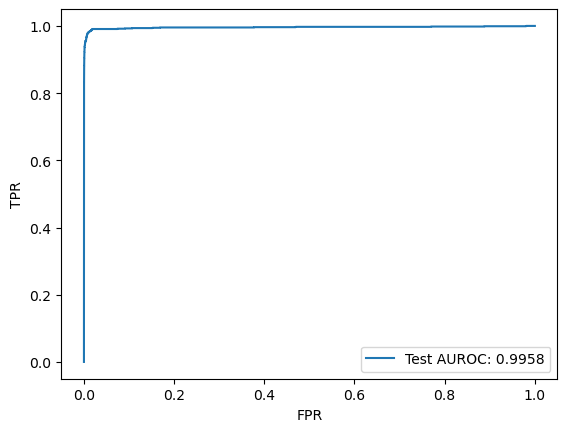

In [5]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.BDT, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

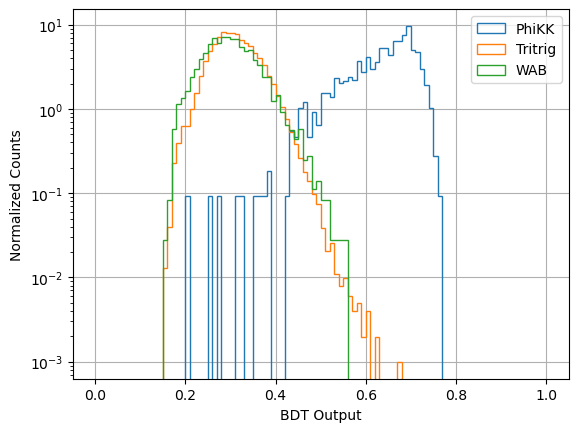

In [6]:
test_df_phiKK.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
#plt.axvline(x=0.4, color='k', linestyle='--', label ="selection line")
plt.xlabel('BDT Output')
plt.ylabel('Normalized Counts')
plt.yscale('log')
plt.legend()

Test AUROC: 0.9931


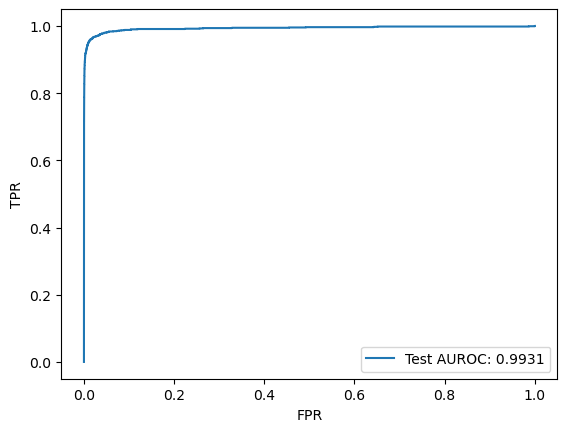

In [7]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_pre, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


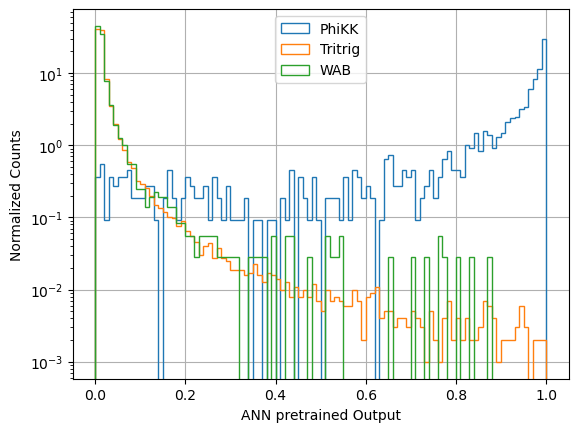

In [8]:
test_df_phiKK.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN pretrained Output')
plt.ylabel('Normalized Counts')
plt.legend()

Test AUROC: 0.9841


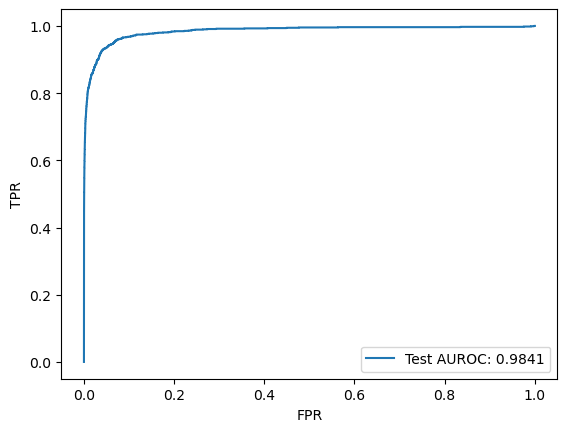

In [9]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_adv, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


In [10]:
a =tpr/fpr

masked = np.ma.masked_invalid(a) # masks inf and nan
if masked.count() == 0: raise ValueError("No finite values")
idx = masked.argmax()

thresholds[idx]

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_5939/3384453741.py:1: RuntimeWarning: divide by zero encountered in divide
  a =tpr/fpr
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_5939/3384453741.py:1: RuntimeWarning: invalid value encountered in divide
  a =tpr/fpr


np.float64(0.9785380477574502)

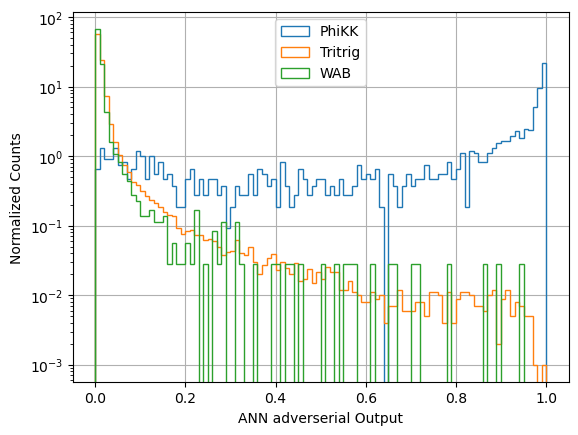

In [11]:
test_df_phiKK.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN adverserial Output')
plt.ylabel('Normalized Counts')
plt.legend()

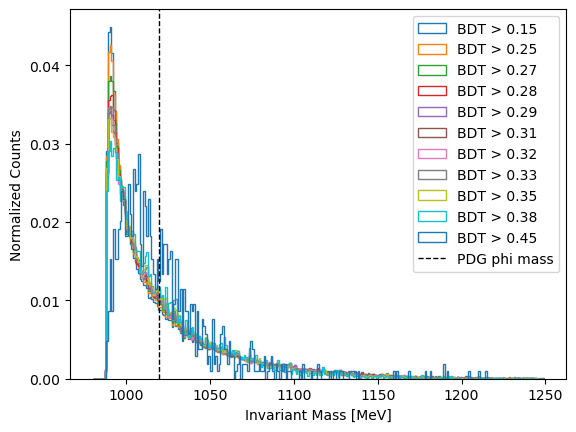

In [12]:
for sel in np.percentile(test_df_bkg['BDT'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['BDT']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'BDT > {sel:.2f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

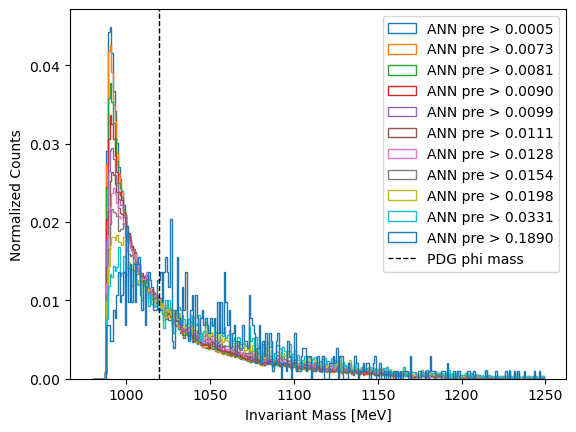

In [13]:
for sel in  np.percentile(test_df_bkg['Class_pre'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_pre']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN pre > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

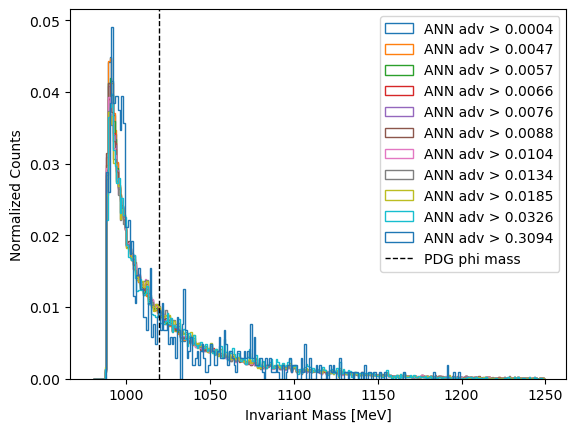

In [14]:
for sel in np.percentile(test_df_bkg['Class_adv'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_adv']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN adv > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

# Compare classifiers on weighted testing data

In [15]:
# Compine dfs according to expected proportions
df_test_combined = pd.concat([test_df_tritrig[0:14963], test_df_wab, test_df_phiKK[0:1]], ignore_index=True, sort=False)

print(len(df_test_combined))

18560


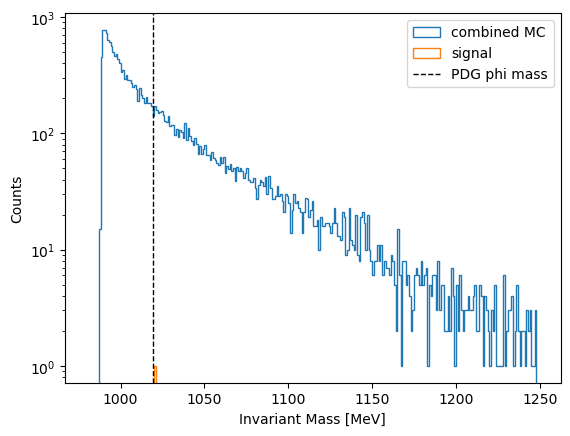

In [17]:
x_vals = 1000*df_test_combined.InvM
x_vals_sig = 1000*df_test_combined.loc[df_test_combined.type=="phiKK"].InvM
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label="combined MC")
plt.hist(x_vals_sig, bins=np.arange(980,1250,1), histtype='step',label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

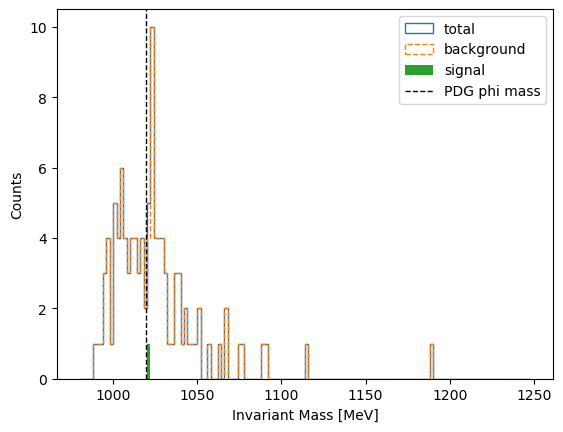

In [18]:
BDT_selection = np.percentile(test_df_bkg['BDT'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['BDT']>BDT_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

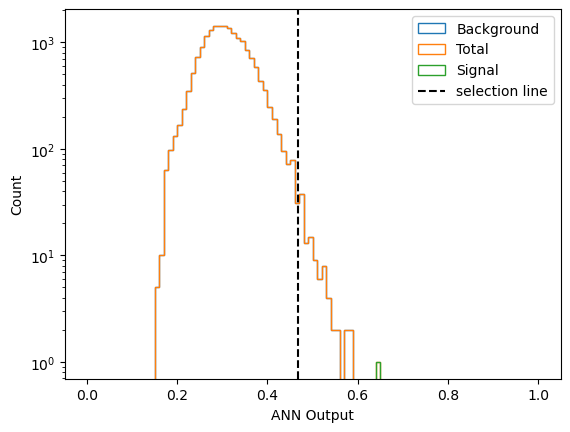

In [19]:
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['BDT'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.axvline(x=BDT_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

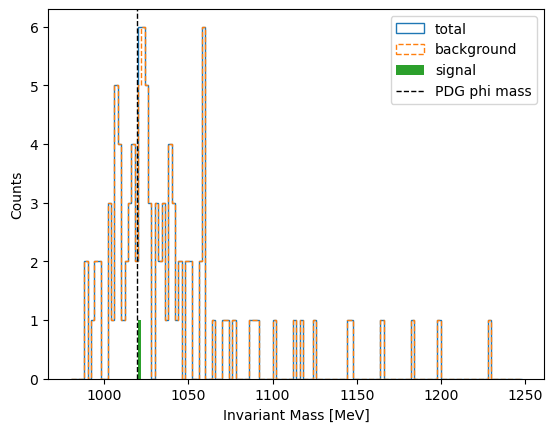

In [20]:
MLP_selection = np.percentile(test_df_bkg['Class_pre'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['Class_pre']>MLP_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

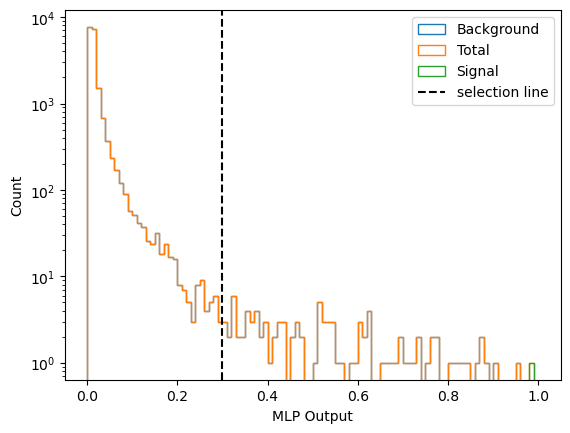

In [21]:
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_pre'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')

plt.axvline(x=MLP_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('MLP Output')
plt.ylabel('Count')

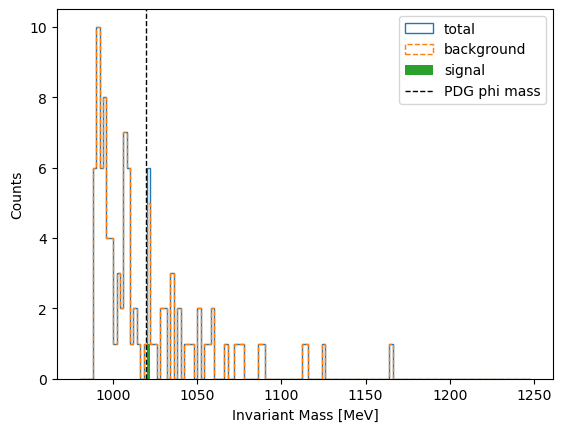

In [22]:
ANN_selection = np.percentile(test_df_bkg['Class_adv'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['Class_adv']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

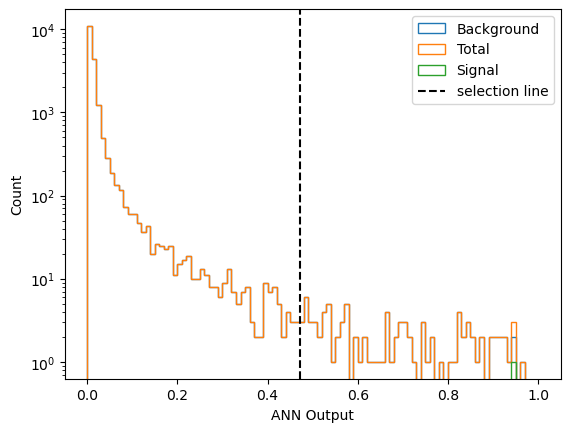

In [23]:
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_adv'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.axvline(x=ANN_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

# Apply ANN to data

In [24]:

X_final = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_data_limited_sideband_b_test.pk')

X_final = X_final.sample(n=14963+1+len(test_df_wab), random_state=42) 

print(len(X_final))

18560


In [25]:
final_classifier = mytools.Classifier(in_features=X_final.shape[1]).to(device)
final_classifier.load_state_dict(torch.load("/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+"_limited_sideband_b.pt", map_location=device))
final_classifier.eval() 

Classifier(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=264, bias=False)
    (1): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=264, out_features=264, bias=False)
    (4): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=264, out_features=128, bias=False)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=128, bias=False)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=64, bias=False)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [26]:
final_dataset = TensorDataset(torch.from_numpy(X_final.to_numpy().astype(np.float32)) )
final_loader = DataLoader(final_dataset, batch_size=124, shuffle=False)

In [27]:
final_pred = mytools.test_final(final_loader, final_classifier, device)
final_pred=torch.sigmoid(torch.tensor(final_pred)).numpy()



(0.0, 10.0)

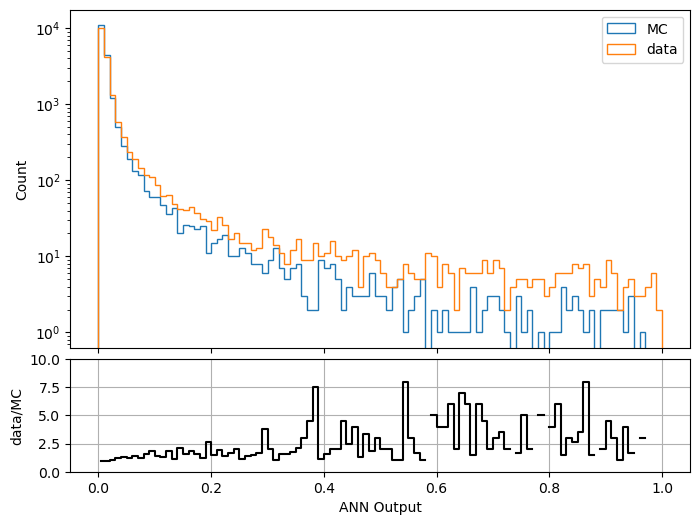

In [29]:
bins = np.arange(0,1.01,0.01)

mc   = df_test_combined['Class_adv'].to_numpy()
data = final_pred

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.grid(True)
ax_bot.set_ylabel('data/MC')
ax_bot.set_xlabel('ANN Output')
ax_bot.set_ylim(0, 10)  # adjust as you like

In [30]:
X_final['pred'] = final_pred
X_final['InvM'] = mytools.get_InvM(X_final)

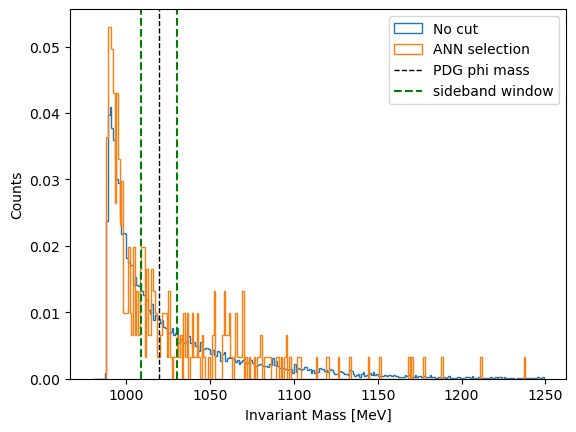

In [31]:
X_final_cut = X_final[X_final['pred']>ANN_selection].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="ANN selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



# Apply BDT to data

In [32]:
bdt_model = joblib.load('/Users/mghrear/data/ML_data/patch/BDT_2021_v9_pass5_limited_sideband_b_model.pkl')
X_final = X_final.drop(columns=['pred','InvM'])

In [33]:
Yhat_final = bdt_model.predict_proba(X_final)[:,1]
X_final['pred'] = Yhat_final
X_final['InvM'] = mytools.get_InvM(X_final)


(0.0, 10.0)

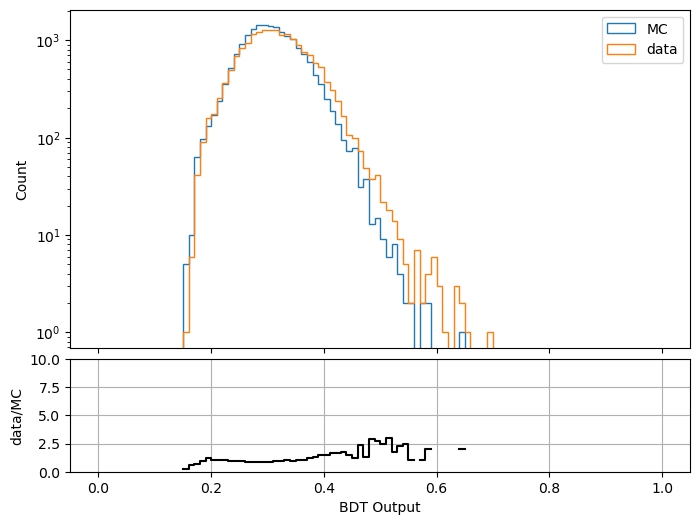

In [36]:
bins = np.arange(0,1.01,0.01)

mc   = df_test_combined['BDT'].to_numpy()
data = Yhat_final

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.grid(True)
ax_bot.set_ylabel('data/MC')
ax_bot.set_xlabel('BDT Output')
ax_bot.set_ylim(0, 10)  # adjust as you like

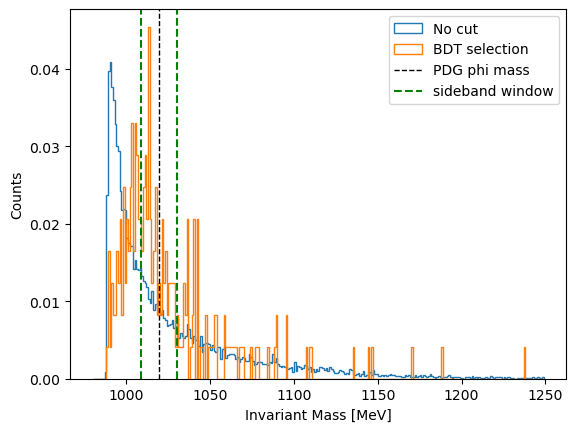

In [37]:
X_final_cut = X_final[X_final['pred']>BDT_selection].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="BDT selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

